# 06_derm7pt — Inspect MEL/NV subset and concept labels

This notebook prepares a **Derm7pt melanoma vs nevus subset** for your thesis.

It will:

1. Load `data/derm7pt/meta/meta.csv`
2. Inspect available diagnoses and concept values
3. Filter only **melanoma** and **nevus** cases
4. Add full image paths for dermoscopic and clinical images
5. Attach official train/valid/test split information from the index files
6. Save a new CSV for later CAM / Finer-CAM / concept evaluation

Expected project structure:

```text
master-thesis/
├── data/
│   └── derm7pt/
│       ├── images/
│       ├── meta/
│       │   ├── meta.csv
│       │   ├── train_indexes.csv
│       │   ├── valid_indexes.csv
│       │   └── test_indexes.csv
│       ├── clinic.html
│       ├── derm.html
│       └── README.txt
└── notebooks/
    └── mel_nv/
        └── 06_derm7pt.ipynb
```

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import random

# If this notebook is saved in notebooks/mel_nv, then ../.. is the repo root.
REPO_ROOT = Path("../..").resolve()

DERM7PT_DIR = REPO_ROOT / "data" / "derm7pt"
IMAGES_DIR = DERM7PT_DIR / "images"
META_DIR = DERM7PT_DIR / "meta"

META_CSV = META_DIR / "meta.csv"
TRAIN_INDEXES = META_DIR / "train_indexes.csv"
VALID_INDEXES = META_DIR / "valid_indexes.csv"
TEST_INDEXES = META_DIR / "test_indexes.csv"

OUTPUT_DIR = DERM7PT_DIR / "mel_nv"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_CSV = OUTPUT_DIR / "derm7pt_mel_nv_concepts.csv"

print("REPO_ROOT:", REPO_ROOT)
print("DERM7PT_DIR exists:", DERM7PT_DIR.exists(), DERM7PT_DIR)
print("IMAGES_DIR exists:", IMAGES_DIR.exists(), IMAGES_DIR)
print("META_CSV exists:", META_CSV.exists(), META_CSV)
print("OUTPUT_CSV:", OUTPUT_CSV)

REPO_ROOT: /Users/choekyelnyungmartsang/Developer/master-thesis
DERM7PT_DIR exists: True /Users/choekyelnyungmartsang/Developer/master-thesis/data/derm7pt
IMAGES_DIR exists: True /Users/choekyelnyungmartsang/Developer/master-thesis/data/derm7pt/images
META_CSV exists: True /Users/choekyelnyungmartsang/Developer/master-thesis/data/derm7pt/meta/meta.csv
OUTPUT_CSV: /Users/choekyelnyungmartsang/Developer/master-thesis/data/derm7pt/mel_nv/derm7pt_mel_nv_concepts.csv


## 1. Load metadata

In [2]:
df = pd.read_csv(META_CSV)

print("Shape:", df.shape)
print("Columns:")
display(pd.DataFrame({"column": df.columns}))

display(df.head())

Shape: (1011, 19)
Columns:


,column
0,case_num
1,diagnosis
2,seven_point_score
3,pigment_network
4,streaks
5,pigmentation
6,regression_structures
7,dots_and_globules
8,blue_whitish_veil
9,vascular_structures


,case_num,diagnosis,seven_point_score,pigment_network,streaks,pigmentation,regression_structures,dots_and_globules,blue_whitish_veil,vascular_structures,level_of_diagnostic_difficulty,elevation,location,sex,management,clinic,derm,case_id,notes
0,1,basal cell carcinoma,0,absent,absent,absent,absent,absent,absent,arborizing,medium,nodular,abdomen,female,excision,NEL/NEL025.JPG,NEL/Nel026.jpg,NaN,NaN
1,2,basal cell carcinoma,1,absent,absent,absent,absent,irregular,absent,absent,low,palpable,head neck,female,excision,NEL/NEL027.JPG,NEL/Nel028.jpg,NaN,NaN
2,3,basal cell carcinoma,1,absent,absent,absent,absent,irregular,absent,arborizing,medium,palpable,head neck,female,excision,NEL/Nel032.jpg,NEL/Nel033.jpg,NaN,NaN
3,4,basal cell carcinoma,4,absent,absent,absent,blue areas,irregular,present,within regression,low,palpable,lower limbs,male,excision,NEL/NEL034.JPG,NEL/Nel035.jpg,NaN,NaN
4,5,basal cell carcinoma,1,absent,absent,diffuse irregular,absent,absent,absent,absent,high,palpable,upper limbs,female,excision,NEL/NEL036.JPG,NEL/Nel037.jpg,NaN,NaN


## 2. Inspect diagnosis categories

This is important because Derm7pt may use names like `melanoma` and `nevus`, but we should confirm the exact spelling before filtering.

In [3]:
diagnosis_counts = df["diagnosis"].value_counts(dropna=False).reset_index()
diagnosis_counts.columns = ["diagnosis", "count"]
display(diagnosis_counts)

,diagnosis,count
0,clark nevus,399
1,melanoma (less than 0.76 mm),102
2,reed or spitz nevus,79
3,melanoma (in situ),64
4,melanoma (0.76 to 1.5 mm),53
5,seborrheic keratosis,45
6,basal cell carcinoma,42
7,dermal nevus,33
8,vascular lesion,29
9,blue nevus,28


## 3. Inspect concept annotation values

These columns are the main reason Derm7pt is useful for your thesis. They can later be used to test whether Finer-CAM highlights melanoma-relevant dermoscopic evidence.

In [4]:
concept_cols = [
    "seven_point_score",
    "pigment_network",
    "streaks",
    "pigmentation",
    "regression_structures",
    "dots_and_globules",
    "blue_whitish_veil",
    "vascular_structures",
]

for col in concept_cols:
    if col in df.columns:
        print("\n" + "=" * 80)
        print(col)
        counts = df[col].value_counts(dropna=False).reset_index()
        counts.columns = [col, "count"]
        display(counts)
    else:
        print("Missing column:", col)


seven_point_score


,seven_point_score,count
0,0,311
1,1,166
2,2,165
3,4,96
4,3,91
5,5,81
6,6,50
7,7,28
8,8,14
9,9,7



pigment_network


,pigment_network,count
0,absent,400
1,typical,381
2,atypical,230



streaks


...

,dots_and_globules,count
0,irregular,448
1,regular,334
2,absent,229



blue_whitish_veil


,blue_whitish_veil,count
0,absent,816
1,present,195



vascular_structures


,vascular_structures,count
0,absent,823
1,dotted,53
2,within regression,46
3,arborizing,31
4,comma,23
5,linear irregular,18
6,hairpin,15
7,wreath,2


## 4. Filter melanoma and nevus cases

We create a binary subset:

- `melanoma` → label `1`
- `nevus` → label `0`

If your metadata uses a different diagnosis spelling, adjust `MEL_DIAGNOSES` or `NV_DIAGNOSES`.

In [5]:
MEL_DIAGNOSES = {
    "melanoma",
    "melanoma (less than 0.76 mm)",
    "melanoma (in situ)",
    "melanoma (0.76 to 1.5 mm)",
    "melanoma (more than 1.5 mm)",
    "melanoma metastasis",
    # "melanosis",
}

NV_DIAGNOSES = {
    "clark nevus",
    "reed or spitz nevus",
    "dermal nevus",
    "blue nevus",
    "congenital nevus",
    "combined nevus",
    "recurrent nevus",
}

diagnosis_to_label = {diagnosis: 1 for diagnosis in MEL_DIAGNOSES}
diagnosis_to_label.update({diagnosis: 0 for diagnosis in NV_DIAGNOSES})

df_subset = df[df["diagnosis"].isin(diagnosis_to_label)].copy()

df_subset["binary_label"] = df_subset["diagnosis"].map(diagnosis_to_label)
df_subset["binary_class"] = df_subset["binary_label"].map({
    0: "nv",
    1: "mel",
})

print("Subset shape:", df_subset.shape)

display(
    df_subset["diagnosis"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "diagnosis", "diagnosis": "count"})
)

display(df_subset.head())

Subset shape: (827, 21)


,count,count
0,clark nevus,399
1,melanoma (less than 0.76 mm),102
2,reed or spitz nevus,79
3,melanoma (in situ),64
4,melanoma (0.76 to 1.5 mm),53
5,dermal nevus,33
6,blue nevus,28
7,melanoma (more than 1.5 mm),28
8,congenital nevus,17
9,combined nevus,13


,case_num,diagnosis,seven_point_score,pigment_network,streaks,pigmentation,regression_structures,dots_and_globules,blue_whitish_veil,vascular_structures,...,elevation,location,sex,management,clinic,derm,case_id,notes,binary_label,binary_class
42,43,blue nevus,0,absent,absent,diffuse regular,absent,absent,absent,absent,...,nodular,acral,female,no further examination,NFL/Nfl039.jpg,NFL/Nfl040.jpg,NaN,NaN,0,nv
43,44,blue nevus,0,absent,absent,diffuse regular,absent,absent,absent,absent,...,palpable,head neck,male,no further examination,NFL/Nfl045.jpg,NFL/Nfl046.jpg,NaN,NaN,0,nv
44,45,blue nevus,0,absent,absent,diffuse regular,absent,absent,absent,absent,...,palpable,lower limbs,male,no further examination,NFL/Nfl047.jpg,NFL/Nfl048.jpg,NaN,NaN,0,nv
45,46,blue nevus,2,typical,absent,absent,absent,absent,present,absent,...,nodular,upper limbs,female,excision,NFL/Nfl049.jpg,NFL/Nfl050.jpg,NaN,NaN,0,nv
46,47,blue nevus,0,absent,absent,diffuse regular,absent,absent,absent,absent,...,palpable,head neck,female,clinical follow up,NGL/Ngl071.jpg,NGL/Ngl072.jpg,NaN,NaN,0,nv


## 5. Add official train / valid / test split

The split files contain row indices. Based on your screenshot, the file has a column named `indexes`.

Important: depending on the dataset version, these indices may refer to the original metadata row index. This notebook attaches the split using the original row index.

In [6]:
def read_index_file(path: Path, split_name: str) -> pd.DataFrame:
    idx_df = pd.read_csv(path)
    if "indexes" not in idx_df.columns:
        raise ValueError(f"Expected column 'indexes' in {path}, found {idx_df.columns.tolist()}")
    idx_df = idx_df[["indexes"]].copy()
    idx_df["split"] = split_name
    return idx_df

split_df = pd.concat([
    read_index_file(TRAIN_INDEXES, "train"),
    read_index_file(VALID_INDEXES, "valid"),
    read_index_file(TEST_INDEXES, "test"),
], ignore_index=True)

print("Split rows:", split_df.shape)
display(split_df["split"].value_counts().reset_index().rename(columns={"index": "split", "split": "count"}))
display(split_df.head())

df_subset = df_subset.copy()
df_subset["original_index"] = df_subset.index

df_subset = df_subset.merge(
    split_df.rename(columns={"indexes": "original_index"}),
    on="original_index",
    how="left",
)

print("Missing split assignments:", df_subset["split"].isna().sum())
display(df_subset["split"].value_counts(dropna=False).reset_index().rename(columns={"index": "split", "split": "count"}))

Split rows: (1011, 2)


,count,count
0,train,413
1,test,395
2,valid,203


,indexes,split
0,16,train
1,17,train
2,22,train
3,27,train
4,29,train


Missing split assignments: 0


,count,count
0,train,346
1,test,320
2,valid,161


## 6. Add full image paths and check files exist

Derm7pt has both:

- `derm`: dermoscopic image path relative to `images/`
- `clinic`: clinical image path relative to `images/`

For your current CAM/Finer-CAM work, **dermoscopic images** are probably the main focus.

In [7]:
df_subset["derm_rel_path"] = df_subset["derm"].astype(str)
df_subset["clinic_rel_path"] = df_subset["clinic"].astype(str)

df_subset["derm_path"] = df_subset["derm_rel_path"].apply(lambda p: str(IMAGES_DIR / p))
df_subset["clinic_path"] = df_subset["clinic_rel_path"].apply(lambda p: str(IMAGES_DIR / p))

df_subset["derm_exists"] = df_subset["derm_path"].apply(lambda p: Path(p).exists())
df_subset["clinic_exists"] = df_subset["clinic_path"].apply(lambda p: Path(p).exists())

print("Dermoscopic images existing:")
display(df_subset["derm_exists"].value_counts(dropna=False).reset_index().rename(columns={"index": "exists", "derm_exists": "count"}))

print("Clinical images existing:")
display(df_subset["clinic_exists"].value_counts(dropna=False).reset_index().rename(columns={"index": "exists", "clinic_exists": "count"}))

display(df_subset[["diagnosis", "binary_class", "split", "derm_rel_path", "derm_exists", "clinic_rel_path", "clinic_exists"]].head())

Dermoscopic images existing:


,count,count
0,True,827


Clinical images existing:


,count,count
0,True,827


,diagnosis,binary_class,split,derm_rel_path,derm_exists,clinic_rel_path,clinic_exists
0,blue nevus,nv,test,NFL/Nfl040.jpg,True,NFL/Nfl039.jpg,True
1,blue nevus,nv,train,NFL/Nfl046.jpg,True,NFL/Nfl045.jpg,True
2,blue nevus,nv,test,NFL/Nfl048.jpg,True,NFL/Nfl047.jpg,True
3,blue nevus,nv,train,NFL/Nfl050.jpg,True,NFL/Nfl049.jpg,True
4,blue nevus,nv,train,NGL/Ngl072.jpg,True,NGL/Ngl071.jpg,True


## 7. Save clean MEL/NV concept CSV

The output CSV keeps the columns that are useful for your thesis:

- labels
- split
- dermoscopic and clinical image paths
- 7-point checklist concepts
- patient metadata
- management and difficulty information

You can later use this CSV for:
- PanDerm inference
- Finer-CAM generation
- concept-level analysis
- dermatologist review sampling

In [8]:
keep_cols = [
    "case_num",
    "case_id",
    "original_index",
    "split",
    "diagnosis",
    "binary_label",
    "binary_class",
    "seven_point_score",
    "pigment_network",
    "streaks",
    "pigmentation",
    "regression_structures",
    "dots_and_globules",
    "blue_whitish_veil",
    "vascular_structures",
    "level_of_diagnostic_difficulty",
    "elevation",
    "location",
    "sex",
    "management",
    "derm_rel_path",
    "derm_path",
    "derm_exists",
    "clinic_rel_path",
    "clinic_path",
    "clinic_exists",
    "notes",
]

existing_keep_cols = [c for c in keep_cols if c in df_subset.columns]
missing_keep_cols = [c for c in keep_cols if c not in df_subset.columns]

if missing_keep_cols:
    print("Columns not found and skipped:", missing_keep_cols)

df_out = df_subset[existing_keep_cols].copy()

df_out.to_csv(OUTPUT_CSV, index=False)

print("Saved:", OUTPUT_CSV)
print("Shape:", df_out.shape)
display(df_out.head())

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/data/derm7pt/mel_nv/derm7pt_mel_nv_concepts.csv
Shape: (827, 27)


,case_num,case_id,original_index,split,diagnosis,binary_label,binary_class,seven_point_score,pigment_network,streaks,...,location,sex,management,derm_rel_path,derm_path,derm_exists,clinic_rel_path,clinic_path,clinic_exists,notes
0,43,NaN,42,test,blue nevus,0,nv,0,absent,absent,...,acral,female,no further examination,NFL/Nfl040.jpg,/Users/choekyelnyungmartsang/Developer/master-...,True,NFL/Nfl039.jpg,/Users/choekyelnyungmartsang/Developer/master-...,True,NaN
1,44,NaN,43,train,blue nevus,0,nv,0,absent,absent,...,head neck,male,no further examination,NFL/Nfl046.jpg,/Users/choekyelnyungmartsang/Developer/master-...,True,NFL/Nfl045.jpg,/Users/choekyelnyungmartsang/Developer/master-...,True,NaN
2,45,NaN,44,test,blue nevus,0,nv,0,absent,absent,...,lower limbs,male,no further examination,NFL/Nfl048.jpg,/Users/choekyelnyungmartsang/Developer/master-...,True,NFL/Nfl047.jpg,/Users/choekyelnyungmartsang/Developer/master-...,True,NaN
3,46,NaN,45,train,blue nevus,0,nv,2,typical,absent,...,upper limbs,female,excision,NFL/Nfl050.jpg,/Users/choekyelnyungmartsang/Developer/master-...,True,NFL/Nfl049.jpg,/Users/choekyelnyungmartsang/Developer/master-...,True,NaN
4,47,NaN,46,train,blue nevus,0,nv,0,absent,absent,...,head neck,female,clinical follow up,NGL/Ngl072.jpg,/Users/choekyelnyungmartsang/Developer/master-...,True,NGL/Ngl071.jpg,/Users/choekyelnyungmartsang/Developer/master-...,True,NaN


## 8. Summary tables for dermatologist discussion

In [9]:
print("Class counts:")
display(df_out.groupby(["split", "diagnosis"]).size().reset_index(name="count"))

for col in concept_cols:
    if col in df_out.columns:
        print("\n" + "=" * 100)
        print(col)
        summary = (
            df_out
            .groupby(["diagnosis", col])
            .size()
            .reset_index(name="count")
            .sort_values(["diagnosis", "count"], ascending=[True, False])
        )
        display(summary)

Class counts:


,split,diagnosis,count
0,test,blue nevus,11
1,test,clark nevus,156
2,test,combined nevus,5
3,test,congenital nevus,4
4,test,dermal nevus,8
5,test,melanoma,1
6,test,melanoma (0.76 to 1.5 mm),18
7,test,melanoma (in situ),26
8,test,melanoma (less than 0.76 mm),40
9,test,melanoma (more than 1.5 mm),15



seven_point_score


,diagnosis,seven_point_score,count
0,blue nevus,0,13
1,blue nevus,1,11
2,blue nevus,2,4
3,clark nevus,0,162
4,clark nevus,1,91
...,...,...,...
70,reed or spitz nevus,4,9
72,reed or spitz nevus,6,7
73,reed or spitz nevus,7,2
74,reed or spitz nevus,8,1



pigment_network


...

,diagnosis,dots_and_globules,count
0,blue nevus,absent,25
1,blue nevus,regular,3
4,clark nevus,regular,219
3,clark nevus,irregular,116
2,clark nevus,absent,64
7,combined nevus,regular,7
6,combined nevus,irregular,4
5,combined nevus,absent,2
10,congenital nevus,regular,10
9,congenital nevus,irregular,6



blue_whitish_veil


,diagnosis,blue_whitish_veil,count
0,blue nevus,absent,24
1,blue nevus,present,4
2,clark nevus,absent,389
3,clark nevus,present,10
5,combined nevus,present,12
4,combined nevus,absent,1
6,congenital nevus,absent,17
7,dermal nevus,absent,31
8,dermal nevus,present,2
9,melanoma,absent,1



vascular_structures


,diagnosis,vascular_structures,count
0,blue nevus,absent,26
1,blue nevus,arborizing,2
2,clark nevus,absent,365
6,clark nevus,within regression,15
4,clark nevus,comma,12
5,clark nevus,dotted,6
3,clark nevus,arborizing,1
7,combined nevus,absent,13
8,congenital nevus,absent,17
9,dermal nevus,absent,22


## 9. Visual inspection helper

This section samples images so you can quickly inspect whether the MEL/NV subset and concept labels make sense.

Change:

- `FILTER_DIAGNOSIS`
- `FILTER_CONCEPT_COLUMN`
- `FILTER_CONCEPT_VALUE`

Examples:

```python
FILTER_DIAGNOSIS = "melanoma"
FILTER_CONCEPT_COLUMN = "blue_whitish_veil"
FILTER_CONCEPT_VALUE = "present"
```

In [10]:
FILTER_DIAGNOSIS = None          # e.g. "melanoma" or "nevus"
FILTER_CONCEPT_COLUMN = None     # e.g. "pigment_network", "streaks", "blue_whitish_veil"
FILTER_CONCEPT_VALUE = None      # e.g. "present", "absent", "atypical", "regular"

sample_df = df_out.copy()

if FILTER_DIAGNOSIS is not None:
    sample_df = sample_df[sample_df["diagnosis"] == FILTER_DIAGNOSIS]

if FILTER_CONCEPT_COLUMN is not None and FILTER_CONCEPT_VALUE is not None:
    sample_df = sample_df[sample_df[FILTER_CONCEPT_COLUMN] == FILTER_CONCEPT_VALUE]

sample_df = sample_df[sample_df["derm_exists"] == True].copy()

print("Available images after filter:", len(sample_df))
display(sample_df.head())

Available images after filter: 827


,case_num,case_id,original_index,split,diagnosis,binary_label,binary_class,seven_point_score,pigment_network,streaks,...,location,sex,management,derm_rel_path,derm_path,derm_exists,clinic_rel_path,clinic_path,clinic_exists,notes
0,43,NaN,42,test,blue nevus,0,nv,0,absent,absent,...,acral,female,no further examination,NFL/Nfl040.jpg,/Users/choekyelnyungmartsang/Developer/master-...,True,NFL/Nfl039.jpg,/Users/choekyelnyungmartsang/Developer/master-...,True,NaN
1,44,NaN,43,train,blue nevus,0,nv,0,absent,absent,...,head neck,male,no further examination,NFL/Nfl046.jpg,/Users/choekyelnyungmartsang/Developer/master-...,True,NFL/Nfl045.jpg,/Users/choekyelnyungmartsang/Developer/master-...,True,NaN
2,45,NaN,44,test,blue nevus,0,nv,0,absent,absent,...,lower limbs,male,no further examination,NFL/Nfl048.jpg,/Users/choekyelnyungmartsang/Developer/master-...,True,NFL/Nfl047.jpg,/Users/choekyelnyungmartsang/Developer/master-...,True,NaN
3,46,NaN,45,train,blue nevus,0,nv,2,typical,absent,...,upper limbs,female,excision,NFL/Nfl050.jpg,/Users/choekyelnyungmartsang/Developer/master-...,True,NFL/Nfl049.jpg,/Users/choekyelnyungmartsang/Developer/master-...,True,NaN
4,47,NaN,46,train,blue nevus,0,nv,0,absent,absent,...,head neck,female,clinical follow up,NGL/Ngl072.jpg,/Users/choekyelnyungmartsang/Developer/master-...,True,NGL/Ngl071.jpg,/Users/choekyelnyungmartsang/Developer/master-...,True,NaN


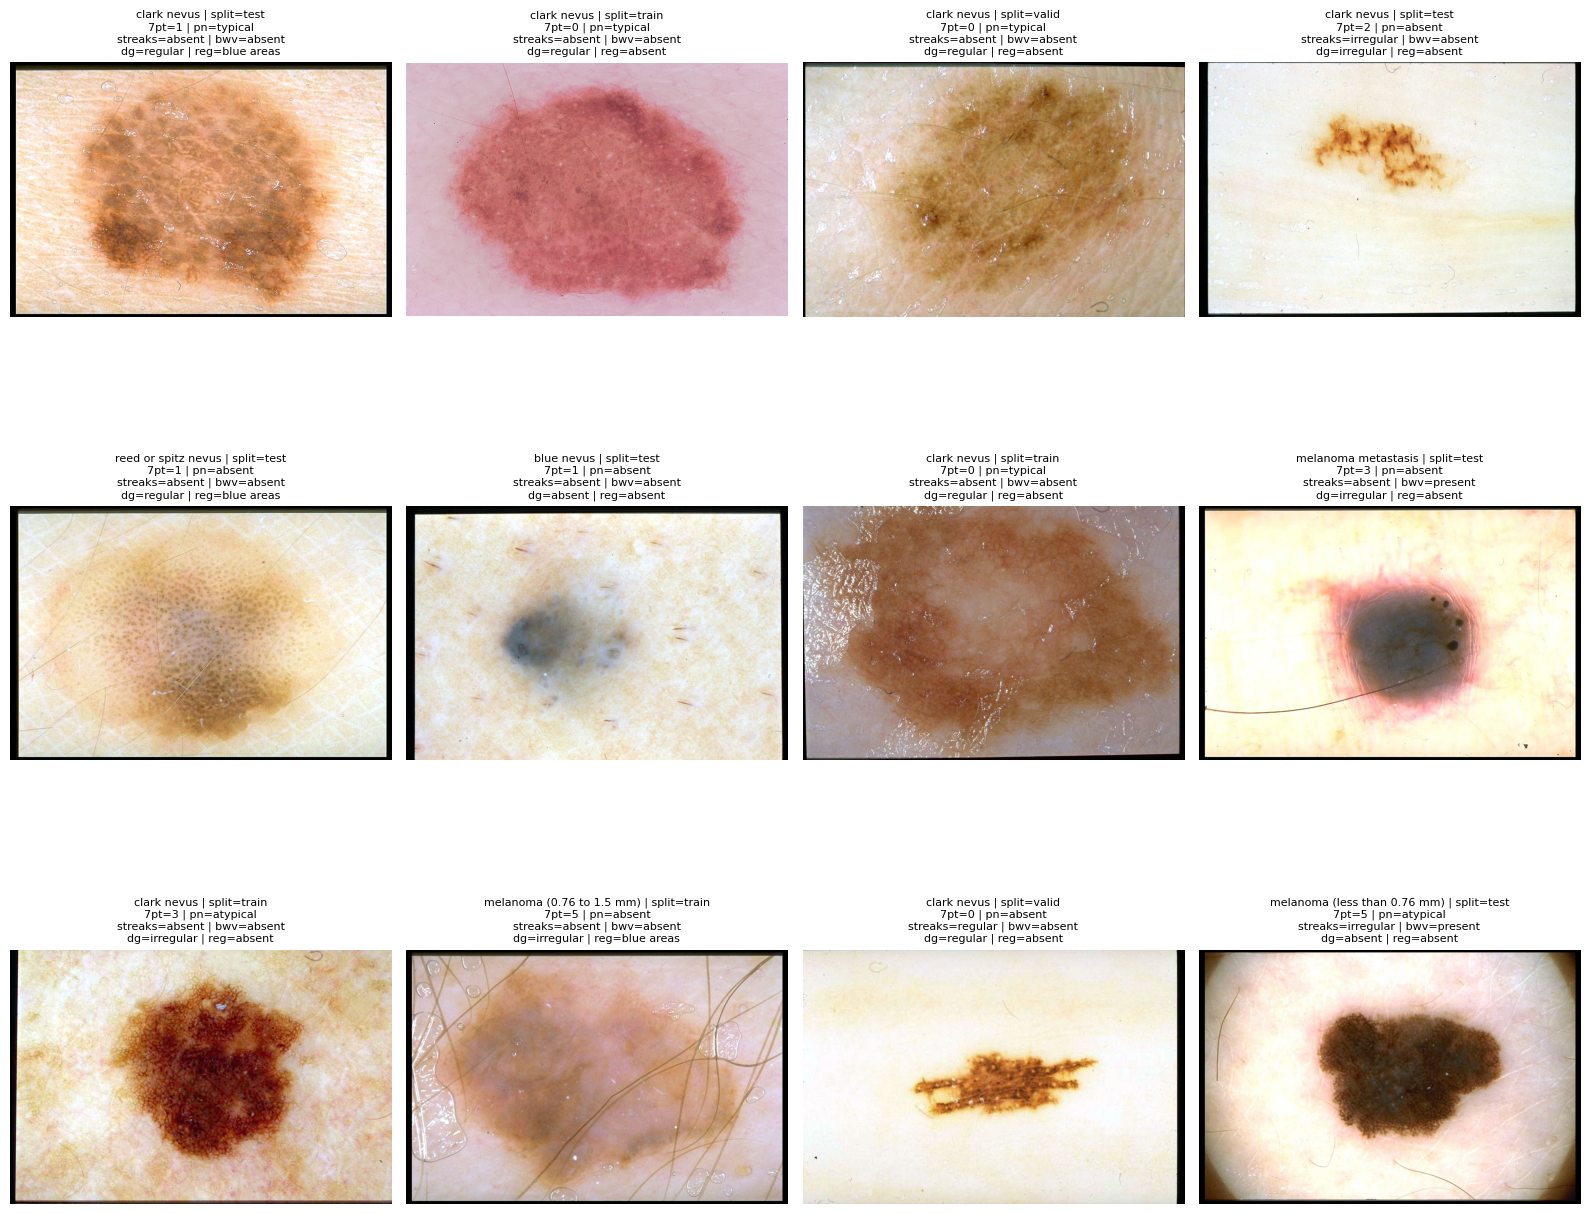

In [11]:
def show_derm_samples(dataframe, n=12, seed=0):
    if len(dataframe) == 0:
        print("No images to show.")
        return

    rows = dataframe.sample(min(n, len(dataframe)), random_state=seed)

    cols = 4
    rows_n = int(np.ceil(len(rows) / cols))
    plt.figure(figsize=(4 * cols, 4.8 * rows_n))

    for i, (_, row) in enumerate(rows.iterrows(), start=1):
        img = Image.open(row["derm_path"]).convert("RGB")
        ax = plt.subplot(rows_n, cols, i)
        ax.imshow(img)
        ax.axis("off")

        title = (
            f'{row["diagnosis"]} | split={row.get("split", "?")}\n'
            f'7pt={row.get("seven_point_score", "?")} | pn={row.get("pigment_network", "?")}\n'
            f'streaks={row.get("streaks", "?")} | bwv={row.get("blue_whitish_veil", "?")}\n'
            f'dg={row.get("dots_and_globules", "?")} | reg={row.get("regression_structures", "?")}'
        )
        ax.set_title(title, fontsize=8)

    plt.tight_layout()
    plt.show()

show_derm_samples(sample_df, n=12, seed=3)

## 10. Optional: create smaller dermatologist review CSV

Use this if you want a balanced sample to show dermatologists.

It samples MEL and NV cases from the available dermoscopic images.

In [12]:
REVIEW_CSV = OUTPUT_DIR / "derm7pt_mel_nv_dermatologist_review_sample.csv"

N_PER_CLASS = 25

review_parts = []
for diagnosis in ["melanoma", "nevus"]:
    part = df_out[(df_out["diagnosis"] == diagnosis) & (df_out["derm_exists"] == True)].copy()
    if len(part) == 0:
        continue
    review_parts.append(part.sample(min(N_PER_CLASS, len(part)), random_state=42))

review_df = pd.concat(review_parts, ignore_index=True) if review_parts else pd.DataFrame()
review_df.to_csv(REVIEW_CSV, index=False)

print("Saved:", REVIEW_CSV)
print("Shape:", review_df.shape)

cols_to_show = [
    "diagnosis",
    "split",
    "seven_point_score",
    "pigment_network",
    "streaks",
    "pigmentation",
    "regression_structures",
    "dots_and_globules",
    "blue_whitish_veil",
    "vascular_structures",
    "derm_rel_path",
]
display(review_df[[c for c in cols_to_show if c in review_df.columns]].head())

Saved: /Users/choekyelnyungmartsang/Developer/master-thesis/data/derm7pt/mel_nv/derm7pt_mel_nv_dermatologist_review_sample.csv
Shape: (1, 27)


,diagnosis,split,seven_point_score,pigment_network,streaks,pigmentation,regression_structures,dots_and_globules,blue_whitish_veil,vascular_structures,derm_rel_path
0,melanoma,test,2,absent,absent,diffuse irregular,white areas,absent,absent,absent,Adl/Adl389.jpg


## 11. Next possible step

After this notebook, the next notebook could do one of these:

1. Run your fine-tuned PanDerm model on this Derm7pt MEL/NV CSV.
2. Generate standard CAM and Finer-CAM for each image.
3. Compare CAM regions against concept labels.
4. Prepare a blinded dermatologist evaluation sheet.